In [1]:
import numpy as np
from spender import SpectrumAutoencoder, SpeculatorActivation
from spender.data.hetdex import HETDEX


data_dir = '/home/qezlou/projects/lae_detection/data/'
instrument = HETDEX()

trainloader = instrument.get_data_loader(data_dir, which="train", batch_size=256)
validloader = instrument.get_data_loader(data_dir, which="valid", batch_size=256)

for k, batch in enumerate(trainloader):
    batch_size = len(batch[0])
    spec, w, z = batch
    assert np.all(~np.isnan(w.numpy())), "w contains NaN values"
    assert not np.any(np.isnan(w.numpy()))
    print(f"Batch {k}: spec shape {spec.shape}, w shape {w.shape}, z shape {z.shape}")

for k, batch in enumerate(validloader):
    batch_size = len(batch[0])
    spec, w, z = batch
    assert np.all(~np.isnan(w.numpy())), "w contains NaN values"
    assert not np.any(np.isnan(w.numpy()))
    print(f"Batch {k}: spec shape {spec.shape}, w shape {w.shape}, z shape {z.shape}")

Batch 0: spec shape torch.Size([256, 1036]), w shape torch.Size([256, 1036]), z shape torch.Size([256])
Batch 1: spec shape torch.Size([256, 1036]), w shape torch.Size([256, 1036]), z shape torch.Size([256])
Batch 2: spec shape torch.Size([256, 1036]), w shape torch.Size([256, 1036]), z shape torch.Size([256])
Batch 3: spec shape torch.Size([256, 1036]), w shape torch.Size([256, 1036]), z shape torch.Size([256])
Batch 4: spec shape torch.Size([256, 1036]), w shape torch.Size([256, 1036]), z shape torch.Size([256])
Batch 5: spec shape torch.Size([256, 1036]), w shape torch.Size([256, 1036]), z shape torch.Size([256])
Batch 6: spec shape torch.Size([256, 1036]), w shape torch.Size([256, 1036]), z shape torch.Size([256])
Batch 7: spec shape torch.Size([256, 1036]), w shape torch.Size([256, 1036]), z shape torch.Size([256])
Batch 8: spec shape torch.Size([256, 1036]), w shape torch.Size([256, 1036]), z shape torch.Size([256])
Batch 9: spec shape torch.Size([256, 1036]), w shape torch.Size(

In [ ]:
2225*256 + 161 + 555*256 + 169

712010

[tensor([[0.9656, 0.9656, 0.9656,  ..., 0.9656, 0.9656, 0.9656],
         [0.9656, 0.9656, 0.9656,  ..., 0.9656, 0.9656, 0.9656],
         [0.9656, 0.9656, 0.9656,  ..., 0.9656, 0.9656, 0.9656],
         ...,
         [0.9656, 0.9656, 0.9656,  ..., 0.9656, 0.9656, 0.9656],
         [0.9656, 0.9656, 0.9656,  ..., 0.9656, 0.9656, 0.9656],
         [0.9656, 0.9656, 0.9656,  ..., 0.9656, 0.9656, 0.9656]]),
 tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 

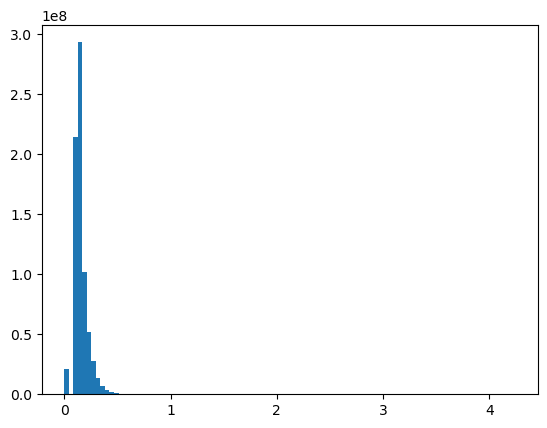

In [ ]:
import h5py
import os
data_dir = '/home/qezlou/projects/lae_detection/data/'
file_name = os.path.join(data_dir, 'fib_spec', 'all_calfibs.h5')
with h5py.File(file_name, 'r') as f:
    calfibe = f['calfibe'][:]
    plt.hist(calfibe.flatten(), bins=100)

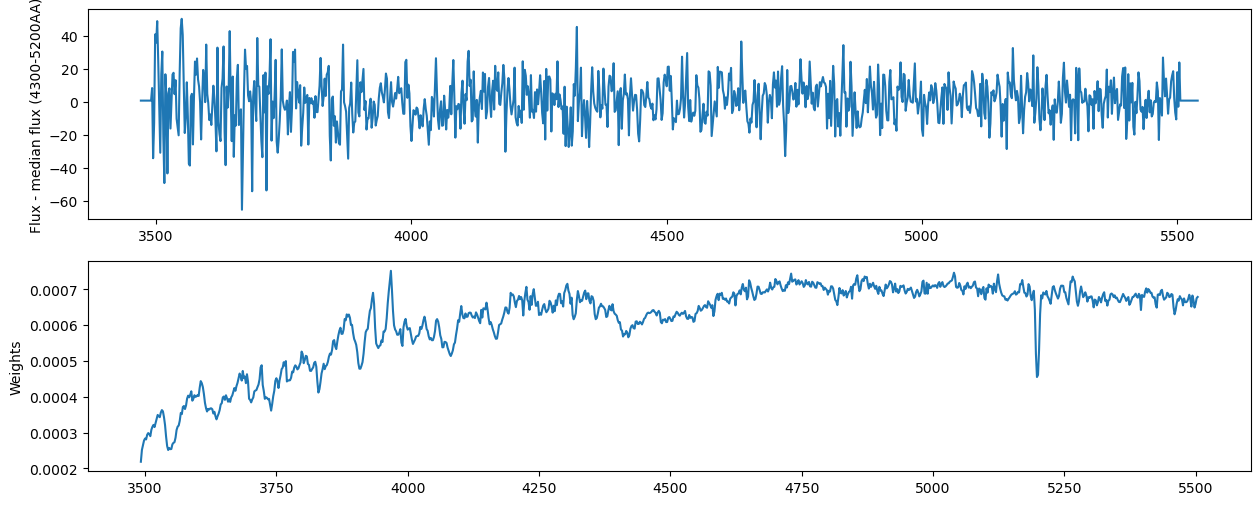

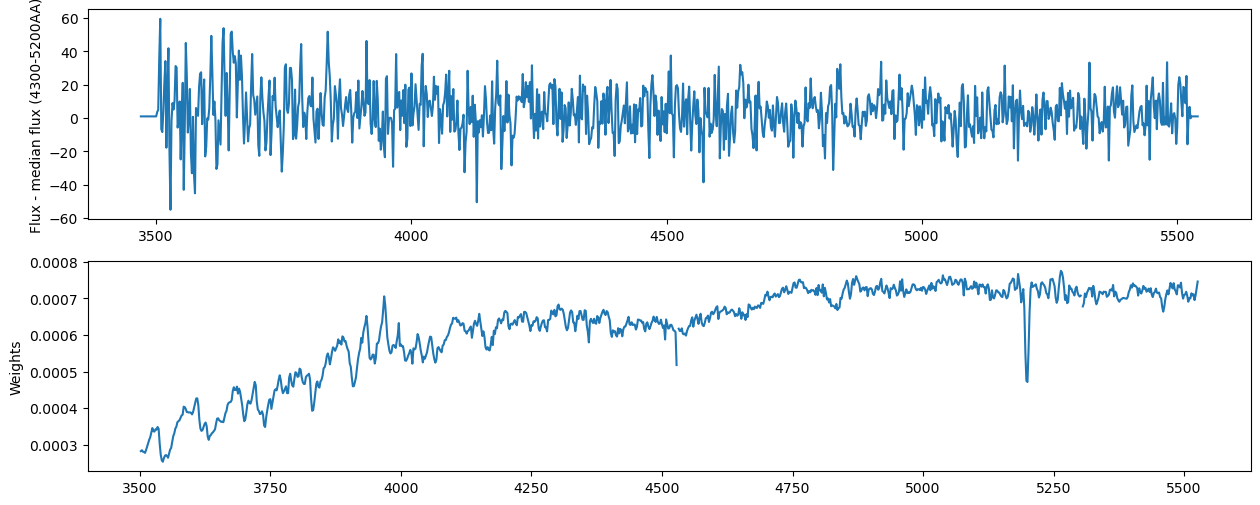

In [ ]:
from matplotlib import pyplot as plt

for ind in [12, 64]:
    fig, ax = plt.subplots(2,1, figsize=(15,6))
    ax[0].plot(instrument._wave_obs.numpy(), spec[ind].numpy())
    ax[0].set_ylabel('Flux - median flux (4300-5200AA)')
    ax[1].plot(instrument._wave_obs.numpy(), w[ind].numpy())
    ax[1].set_ylabel('Weights')

In [ ]:
import h5py
with h5py.File('/home/qezlou/projects/lae_detection/data/fib_spec/all_calfibs.h5','r') as f:
    print(f['calfib'].shape)  # Should print (569, 2225)

(712522, 1036)


2225*

## Load the trained model:

In [ ]:
from  accelerate import Accelerator
import torch
accelerator = Accelerator(mixed_precision='fp16')

/home/qezlou/miniconda3/envs/hetgen/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
import numpy as np
from matplotlib import pyplot as plt
import corner
import umap
import torch

def plot_diagnostic(saved_file, wave_rest= torch.arange(3470, 5542, 2, dtype=torch.float32), latents=2):

    checkpoint = torch.load(saved_file, map_location='cpu')
    losses = np.array(checkpoint['losses'])


    fig, ax = plt.subplots(figsize=(10,6))
    ax.plot(losses[:,0], label='Train Loss')
    ax.plot(losses[:,1], label='Val Loss')
    ax.set_ylim((0.35, 0.45))
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'1000 fibers')
    ax.legend()


    from spender import SpectrumAutoencoder, SpeculatorActivation
    from spender.data.hetdex import HETDEX

    instrument = HETDEX()
    print(f'wave_rest length: {len(wave_rest)}')
    model = SpectrumAutoencoder(
            instrument,
            wave_rest,
            n_latent=latents,
            act=(SpeculatorActivation(64), SpeculatorActivation(256), SpeculatorActivation(1024), SpeculatorActivation(len(wave_rest), plus_one=True)),
    )

    # Load weights into model
    model.load_state_dict(checkpoint["model"])
    model.to('cpu')
    model.eval()

    from scipy.ndimage import gaussian_filter1d

    encoded = []
    with torch.no_grad():
        spec, w, z = next(iter(validloader))
        batch_size = len(spec)
        recon_spec = model(spec)
        s = model.encode(spec).numpy()
        encoded.append(s)
        ind = np.random.choice(batch_size, size=4, replace=False)
        for i in ind:
            fig, ax = plt.subplots(1,1, figsize=(15,4))
            
            ax.plot(instrument.wave_obs.numpy(), spec[i].numpy(), label='Original Spectrum')
            ax.set_ylabel('flux / median flux (4300-5200AA)')
            ax.plot(instrument.wave_obs.numpy(), recon_spec[i].detach().numpy(), label='Reconstructed Spectrum')
            ax.fill_between(instrument.wave_obs.numpy(), recon_spec[i].detach().numpy() - 1/np.sqrt(w[i].numpy()), recon_spec[i].detach().numpy() + 1/np.sqrt(w[i].numpy()), color='gray', alpha=0.5, label='1-sigma interval')
            
            ax.set_ylim([-50, 50])
            ax.legend()
            plt.suptitle(f'Validation, latents={latents}')
            plt.show()

    encoded = np.vstack(encoded)         
    print(model)

    fig = corner.corner(encoded, labels=[f'Latent {i+1}' for i in range(latents)], show_titles=True)
    
    reducer = umap.UMAP()
    embedding = reducer.fit_transform(encoded)
    fig, ax = plt.subplots(1,1, figsize=(8,6))
    ax.scatter(embedding[:,0], embedding[:,1], s=1)


/home/qezlou/miniconda3/envs/hetgen/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/tmp/ipykernel_120195/2498533757.py:55: RuntimeWarning: divide by zero encountered in divide
  ax.fill_between(instrument._wave_obs.numpy(), recon_spec[i].detach().numpy() - 1/np.sqrt(w[i].numpy()), recon_spec[i].detach().numpy() + 1/np.sqrt(w[i].numpy()), color='gray', alpha=0.5, label='1-sigma interval')


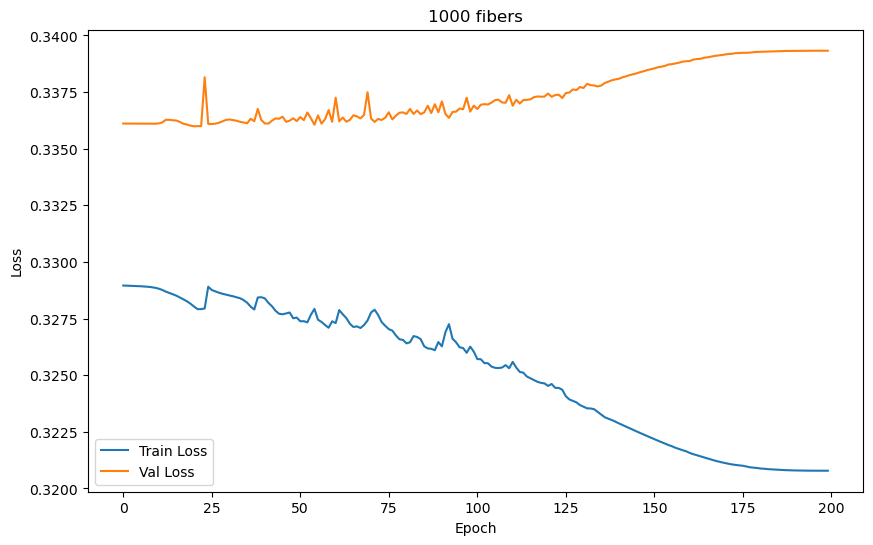

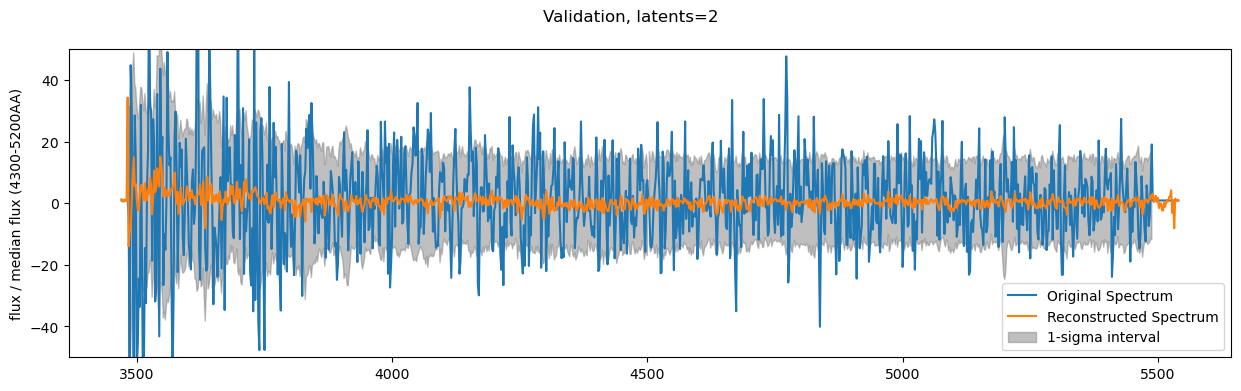

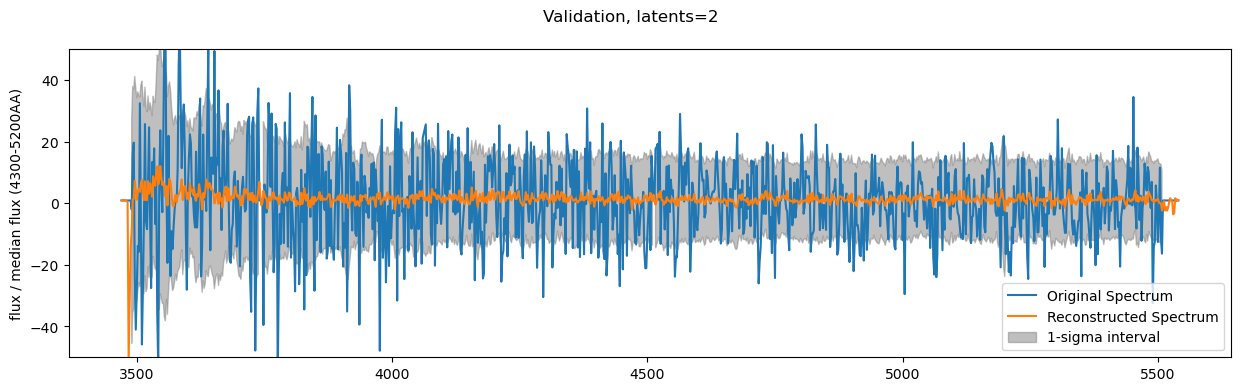

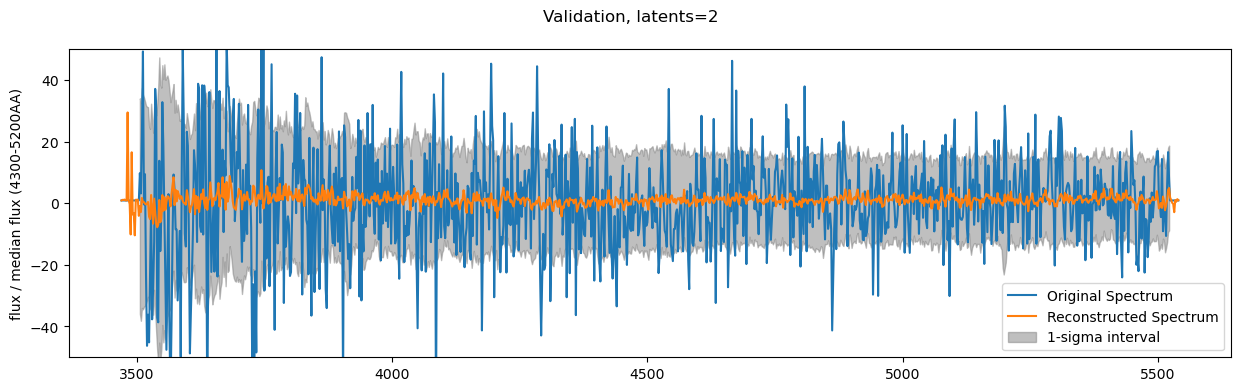

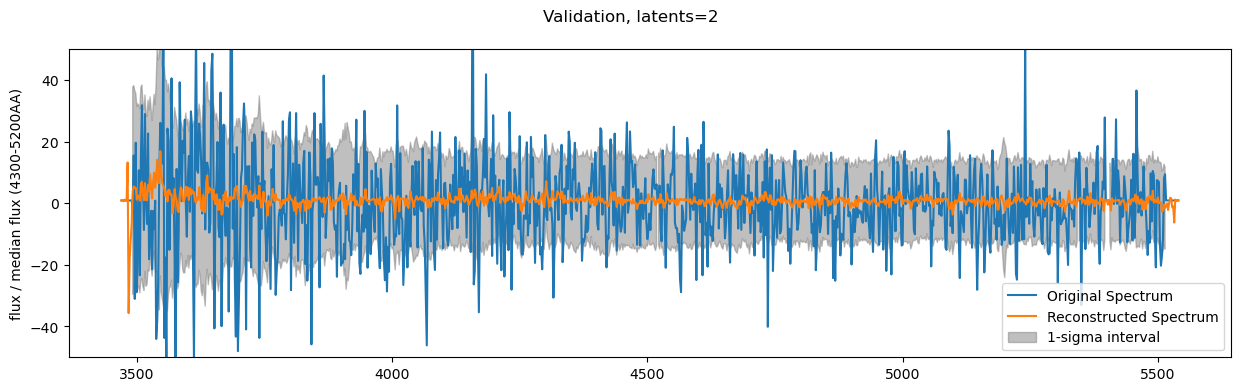

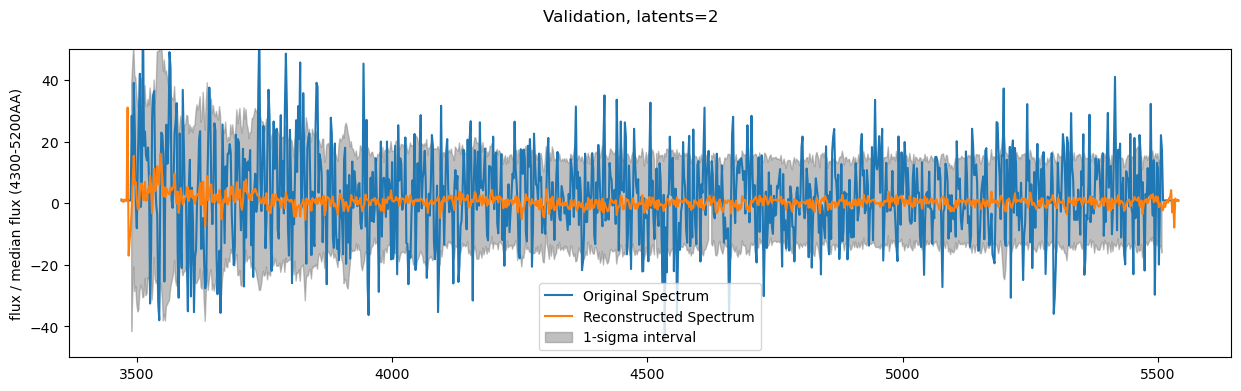

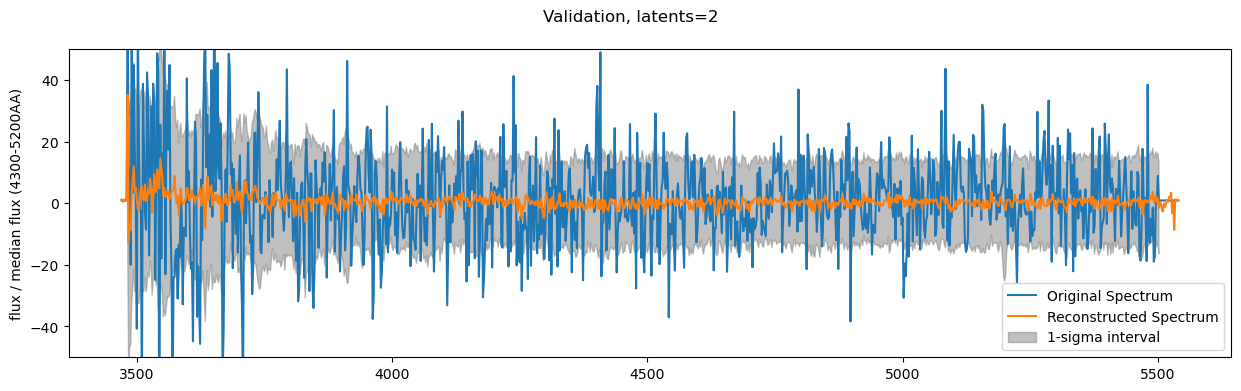

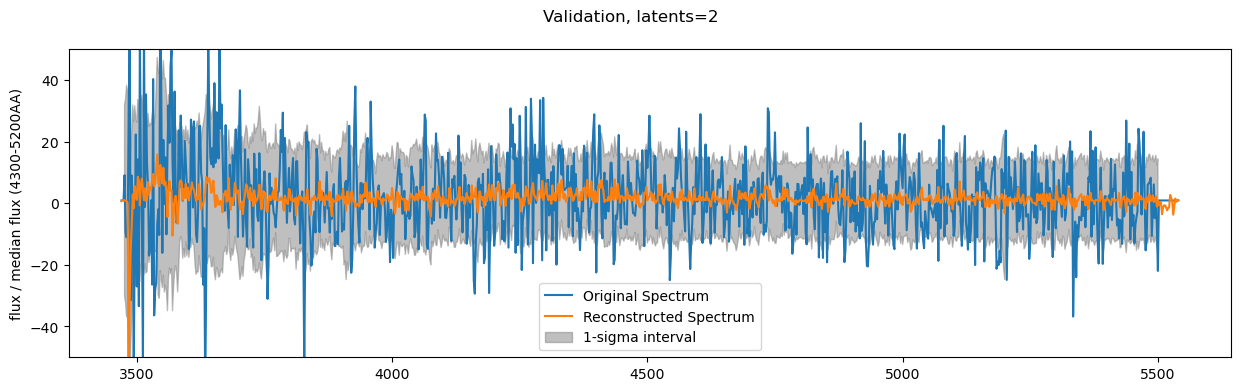

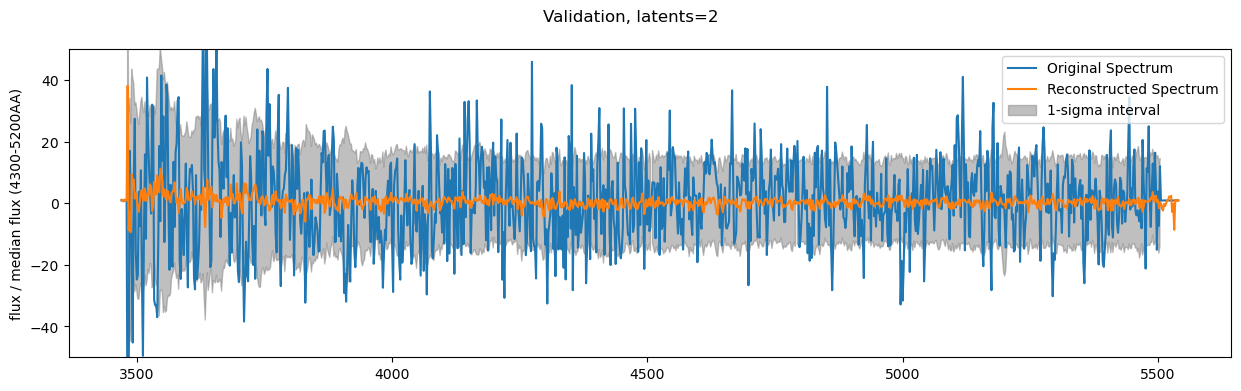

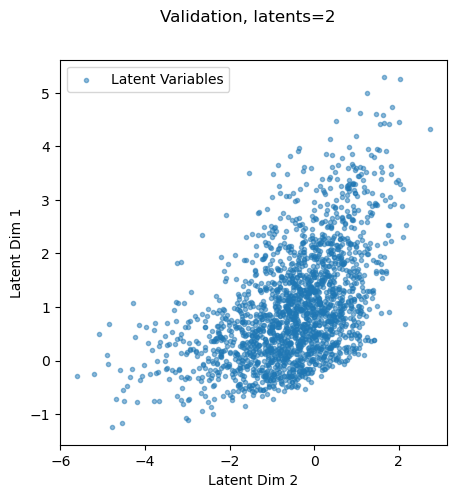

(976, 2)
SpectrumAutoencoder(
  (encoder): SpectrumEncoder(
    (instrument): HETDEX()
    (conv1): Sequential(
      (0): Conv1d(1, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): InstanceNorm1d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): PReLU(num_parameters=128)
      (3): Dropout(p=0, inplace=False)
    )
    (conv2): Sequential(
      (0): Conv1d(128, 256, kernel_size=(11,), stride=(1,), padding=(5,))
      (1): InstanceNorm1d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): PReLU(num_parameters=256)
      (3): Dropout(p=0, inplace=False)
    )
    (conv3): Sequential(
      (0): Conv1d(256, 512, kernel_size=(21,), stride=(1,), padding=(10,))
      (1): InstanceNorm1d(512, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): PReLU(num_parameters=512)
      (3): Dropout(p=0, inplace=False)
    )
    (pool1): MaxPool1d(kernel_size=5, stride=5, padding=2, dilation=1, ceil_mode=

In [ ]:
plot_diagnostic(saved_file = '/home/qezlou/projects/lae_detection/data/models/m_1000_sample.pt')

/tmp/ipykernel_99927/1746069349.py:54: RuntimeWarning: divide by zero encountered in divide
  ax.fill_between(instrument._wave_obs.numpy(), recon_spec[i].detach().numpy() - 1/np.sqrt(w[i].numpy()), recon_spec[i].detach().numpy() + 1/np.sqrt(w[i].numpy()), color='gray', alpha=0.5, label='1-sigma interval')


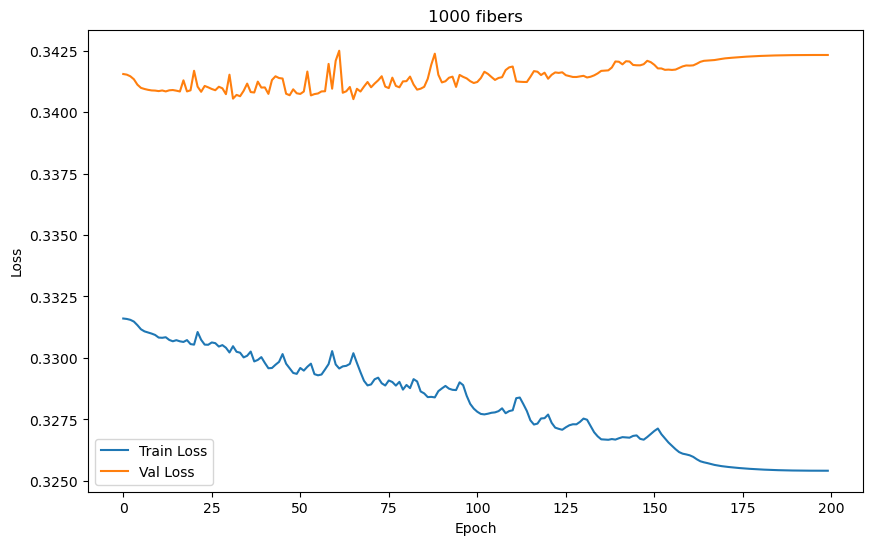

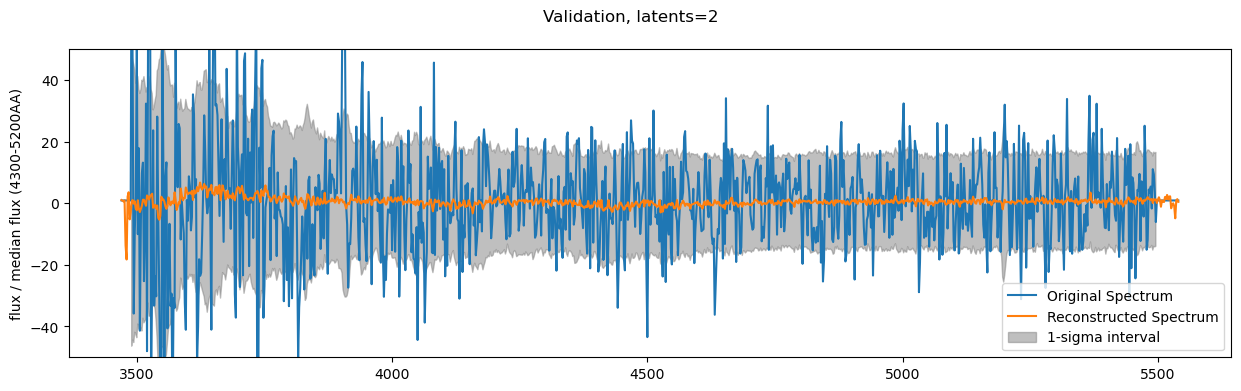

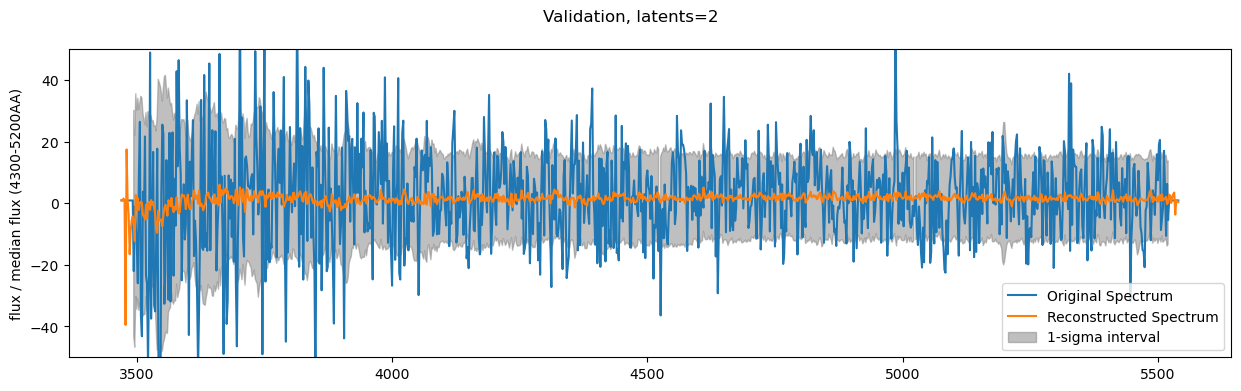

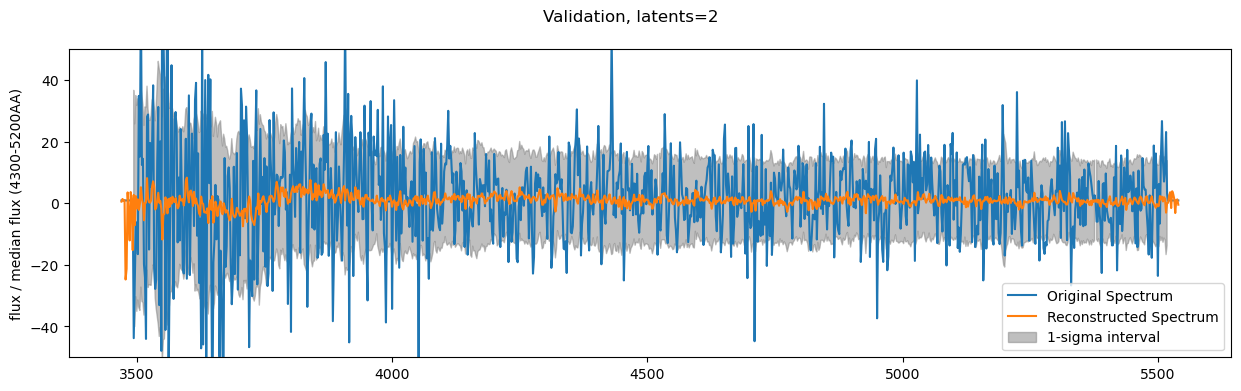

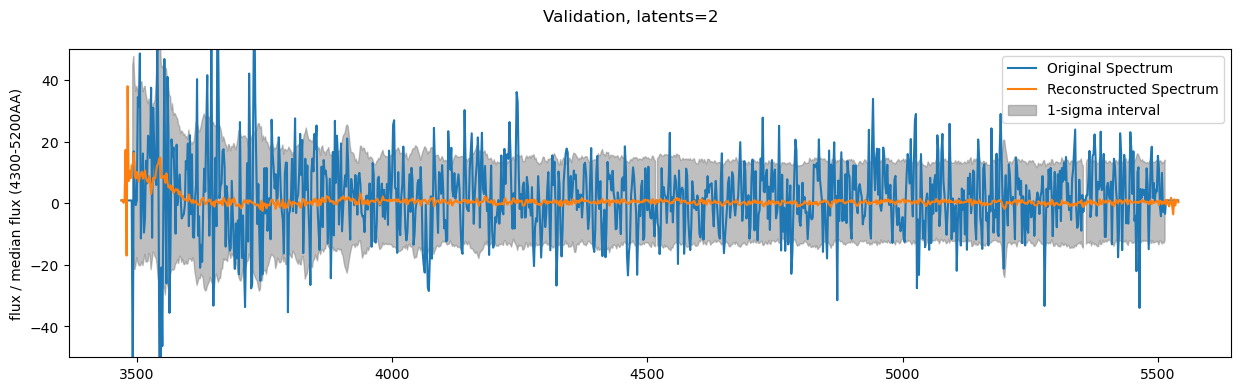

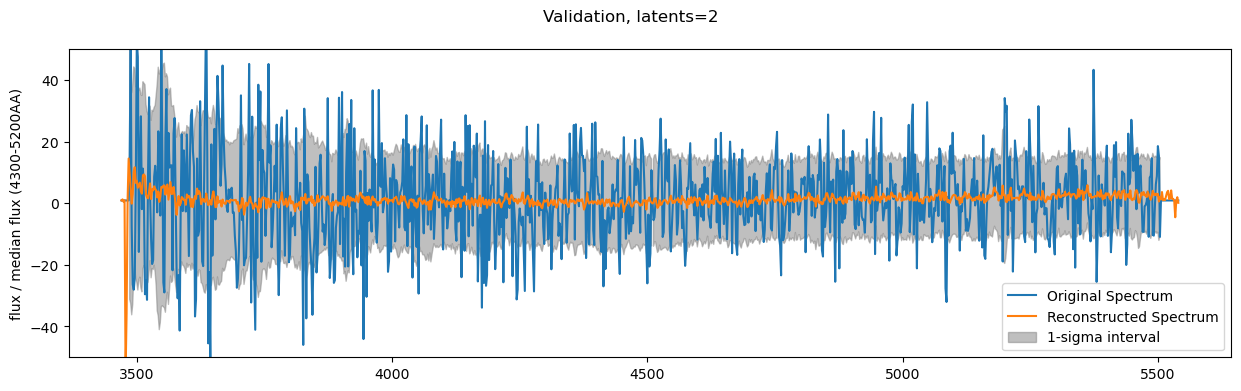

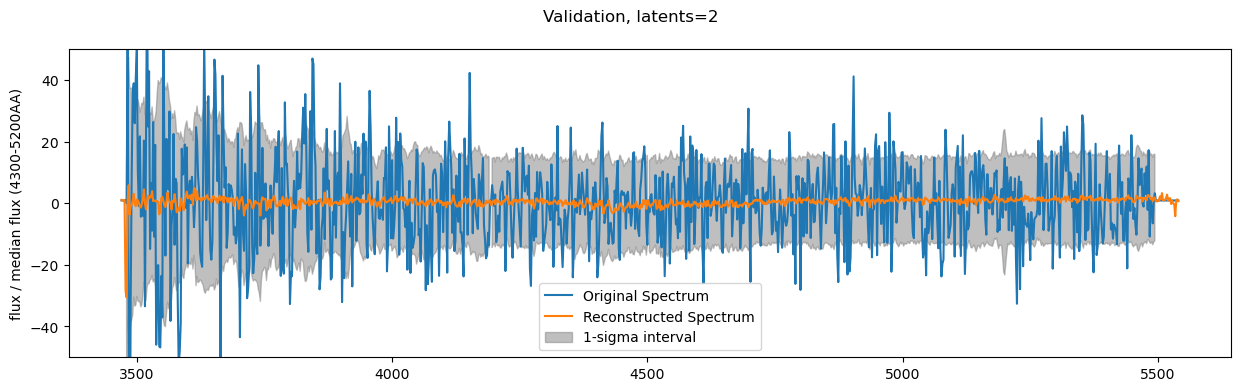

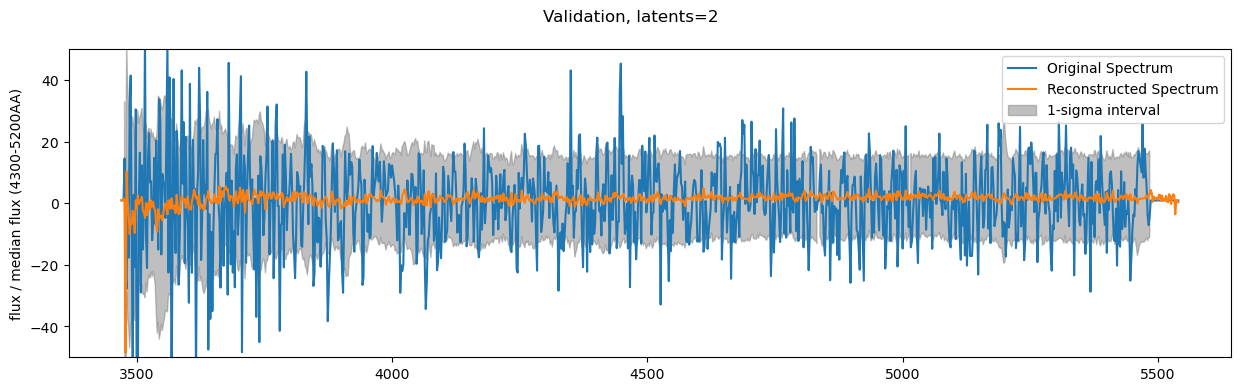

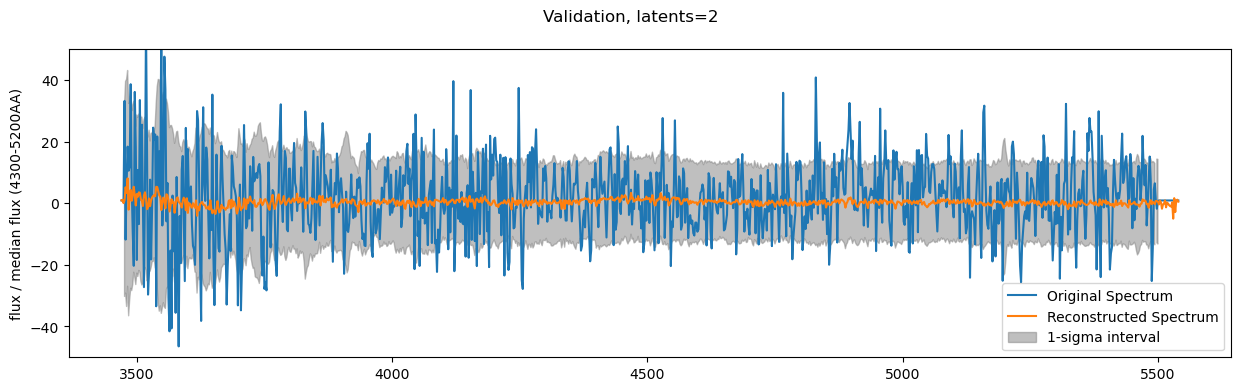

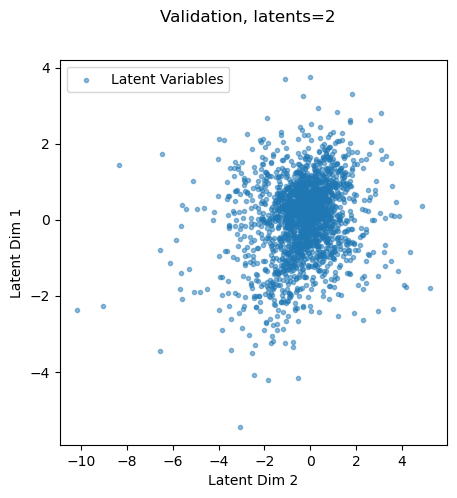

(976, 2)
SpectrumAutoencoder(
  (encoder): SpectrumEncoder(
    (instrument): HETDEX()
    (conv1): Sequential(
      (0): Conv1d(1, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): InstanceNorm1d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): PReLU(num_parameters=128)
      (3): Dropout(p=0, inplace=False)
    )
    (conv2): Sequential(
      (0): Conv1d(128, 256, kernel_size=(11,), stride=(1,), padding=(5,))
      (1): InstanceNorm1d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): PReLU(num_parameters=256)
      (3): Dropout(p=0, inplace=False)
    )
    (conv3): Sequential(
      (0): Conv1d(256, 512, kernel_size=(21,), stride=(1,), padding=(10,))
      (1): InstanceNorm1d(512, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): PReLU(num_parameters=512)
      (3): Dropout(p=0, inplace=False)
    )
    (pool1): MaxPool1d(kernel_size=5, stride=5, padding=2, dilation=1, ceil_mode=

In [ ]:
plot_diagnostic(saved_file = '/home/qezlou/projects/lae_detection/data/models/m_10000_sample.pt')

In [ ]:
encoded

NameError: name 'encoded' is not defined

/tmp/ipykernel_120195/1291880128.py:56: RuntimeWarning: divide by zero encountered in divide
  ax.fill_between(instrument._wave_obs.numpy(), recon_spec[i].detach().numpy() - 1/np.sqrt(w[i].numpy()), recon_spec[i].detach().numpy() + 1/np.sqrt(w[i].numpy()), color='gray', alpha=0.5, label='1-sigma interval')


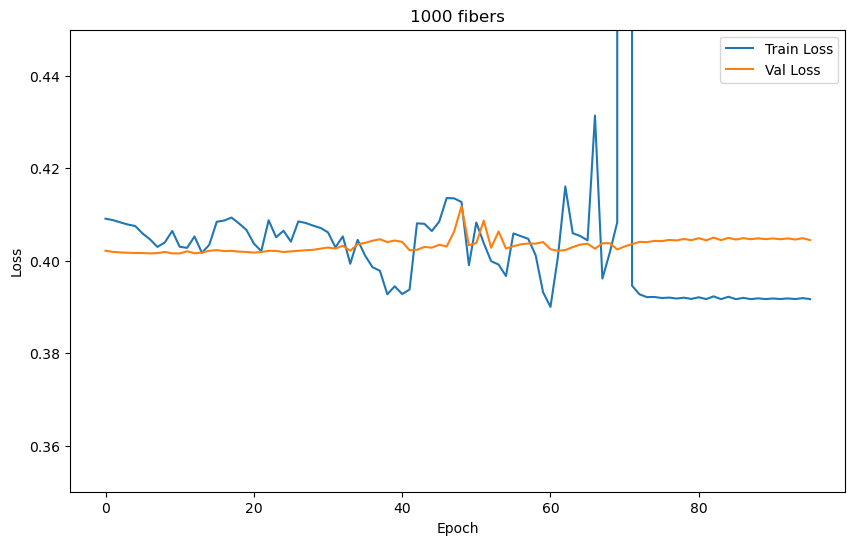

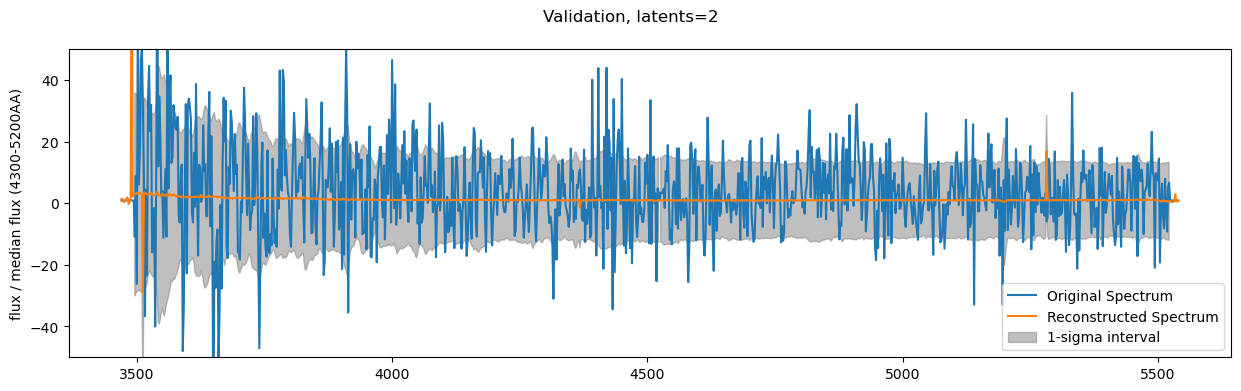

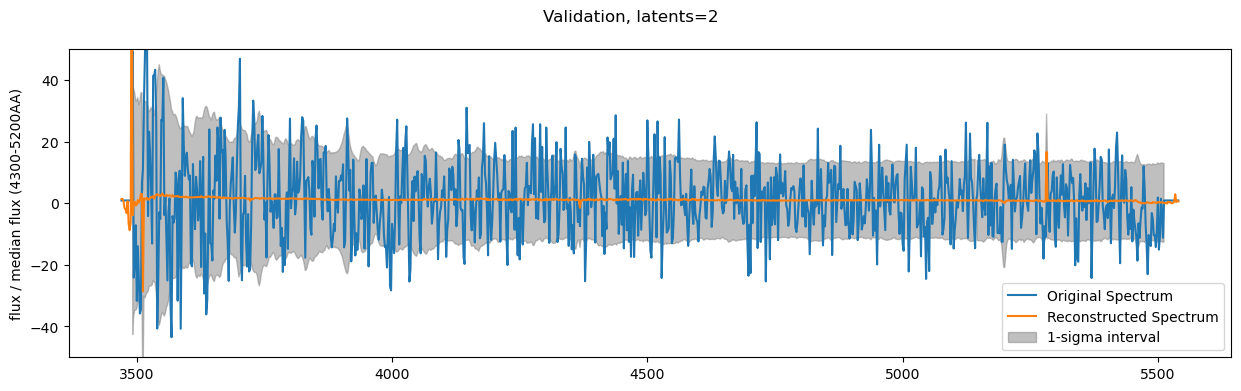

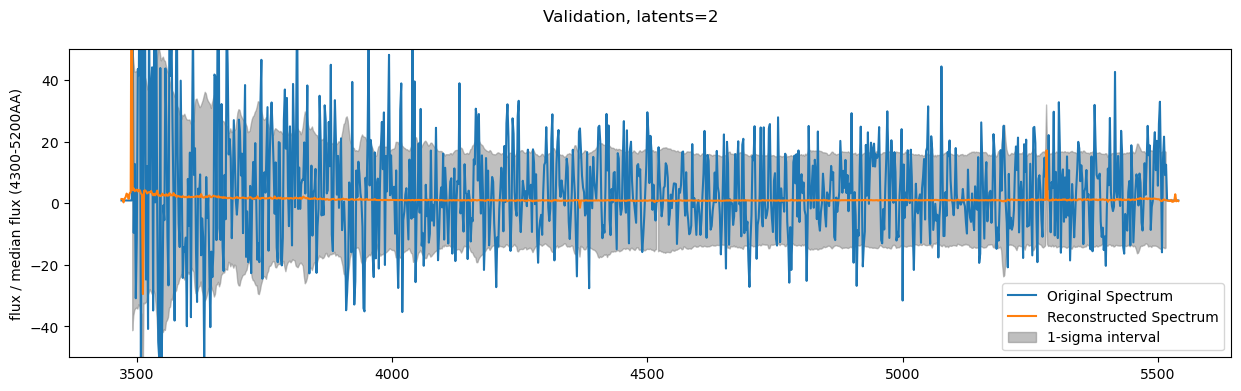

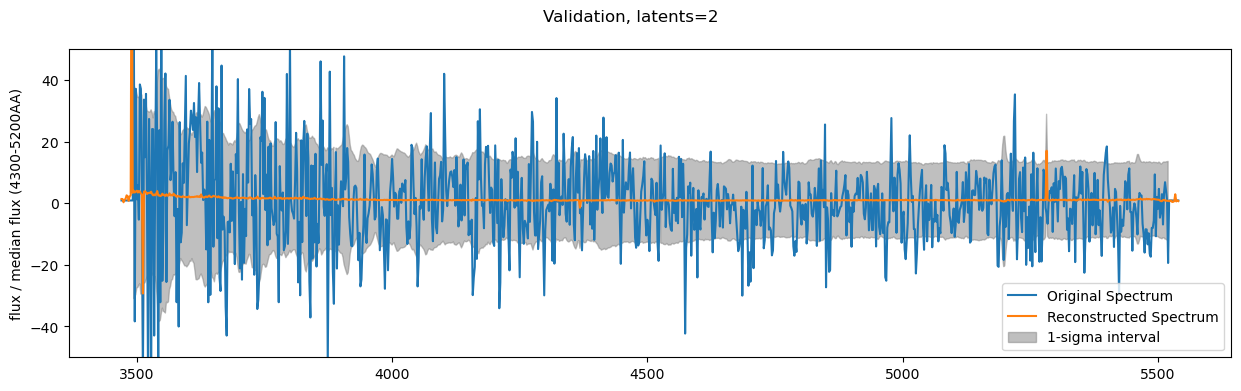

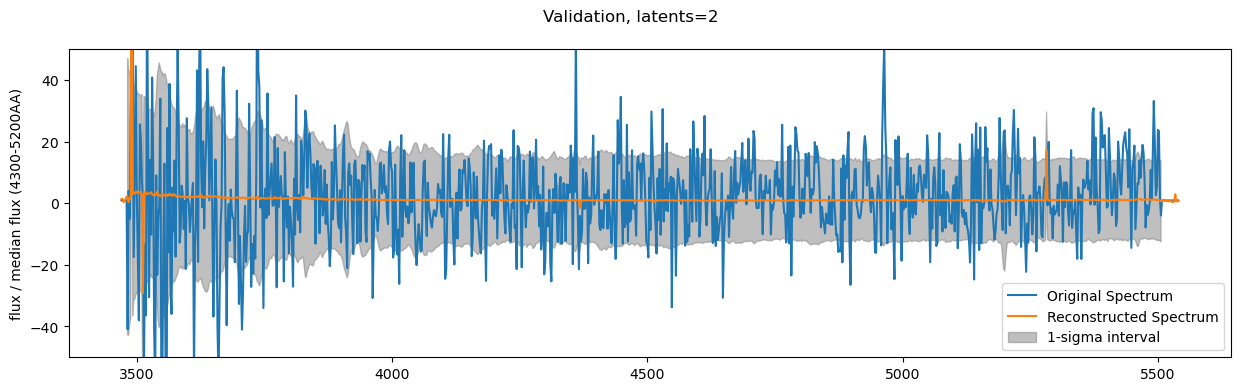

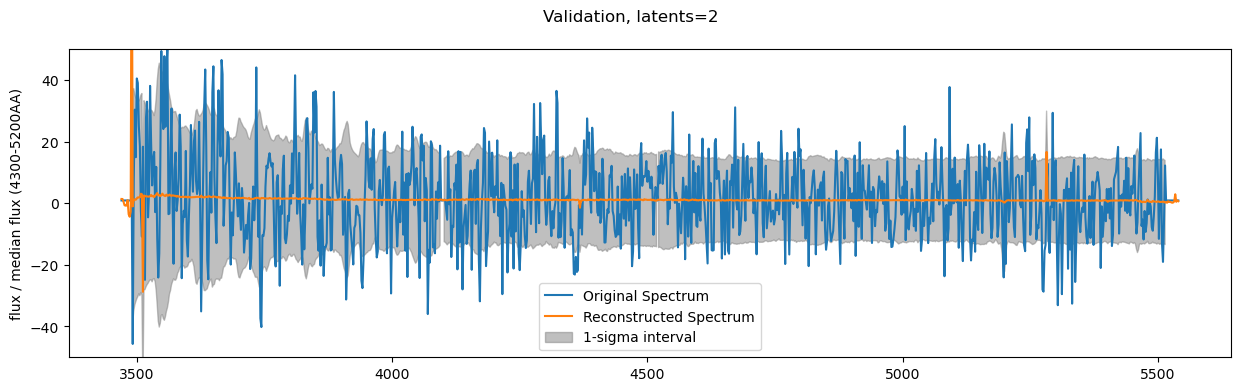

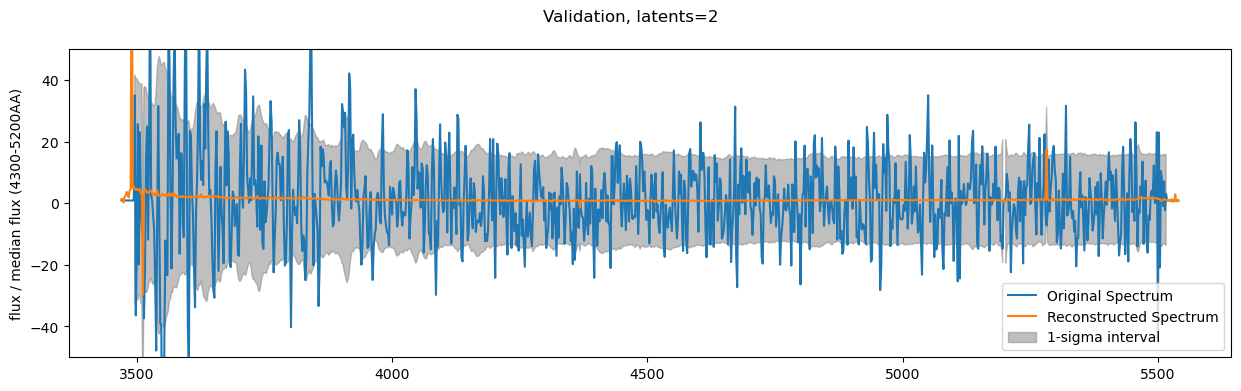

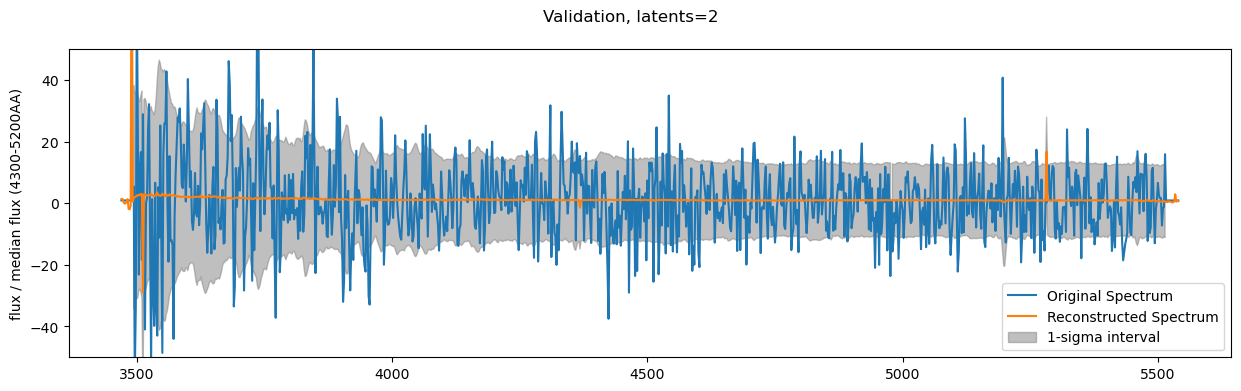

SpectrumAutoencoder(
  (encoder): SpectrumEncoder(
    (instrument): HETDEX()
    (conv1): Sequential(
      (0): Conv1d(1, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): InstanceNorm1d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): PReLU(num_parameters=128)
      (3): Dropout(p=0, inplace=False)
    )
    (conv2): Sequential(
      (0): Conv1d(128, 256, kernel_size=(11,), stride=(1,), padding=(5,))
      (1): InstanceNorm1d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): PReLU(num_parameters=256)
      (3): Dropout(p=0, inplace=False)
    )
    (conv3): Sequential(
      (0): Conv1d(256, 512, kernel_size=(21,), stride=(1,), padding=(10,))
      (1): InstanceNorm1d(512, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): PReLU(num_parameters=512)
      (3): Dropout(p=0, inplace=False)
    )
    (pool1): MaxPool1d(kernel_size=5, stride=5, padding=2, dilation=1, ceil_mode=False)
  

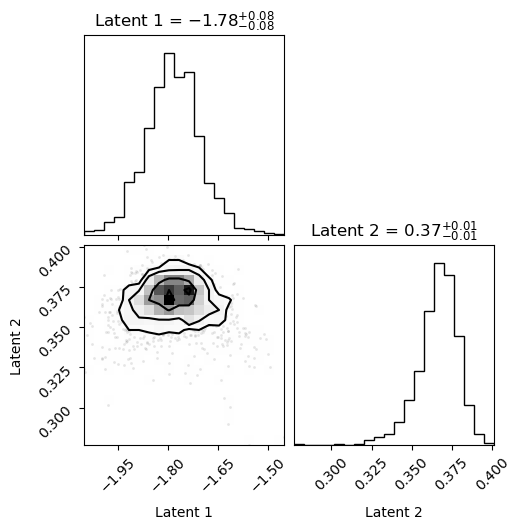

In [ ]:
plot_diagnostic(saved_file = '/home/qezlou/projects/lae_detection/data/models/model_7e5.pt')

wave_rest length: 1036


/tmp/ipykernel_13474/1107196012.py:56: RuntimeWarning: divide by zero encountered in divide
  ax.fill_between(instrument.wave_obs.numpy(), recon_spec[i].detach().numpy() - 1/np.sqrt(w[i].numpy()), recon_spec[i].detach().numpy() + 1/np.sqrt(w[i].numpy()), color='gray', alpha=0.5, label='1-sigma interval')


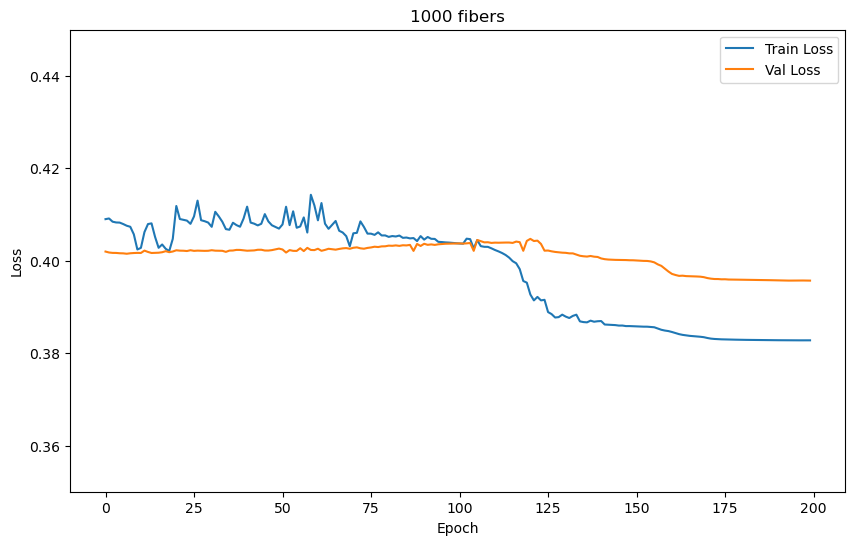

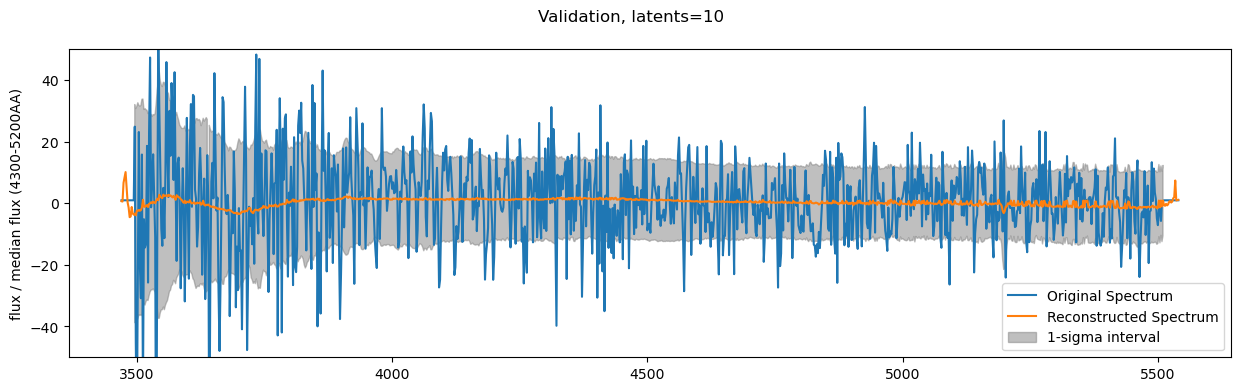

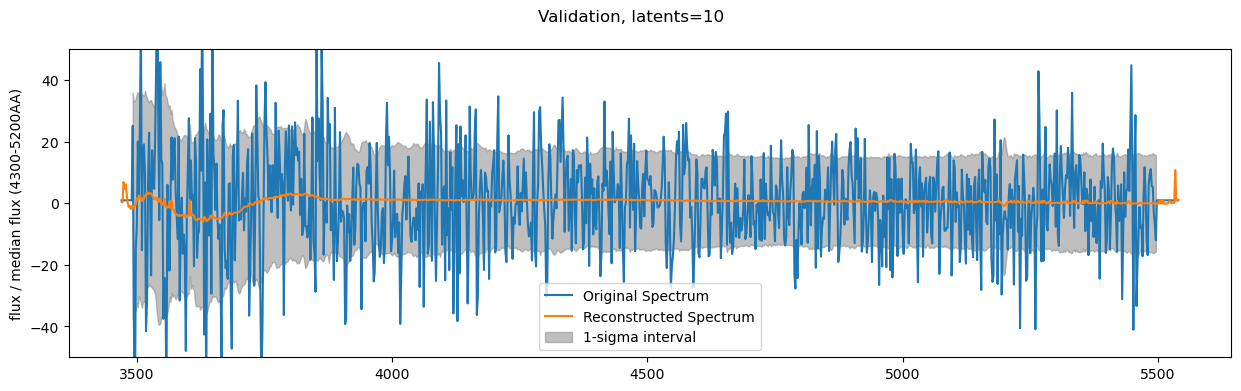

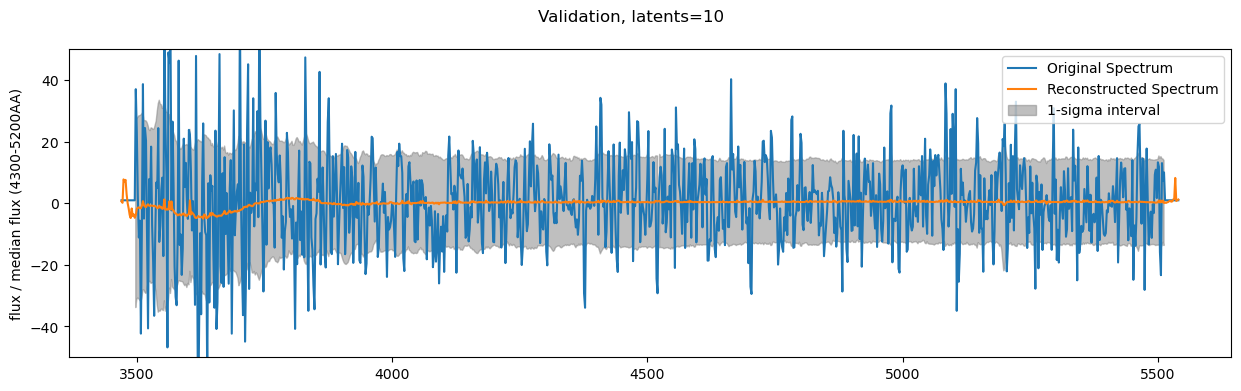

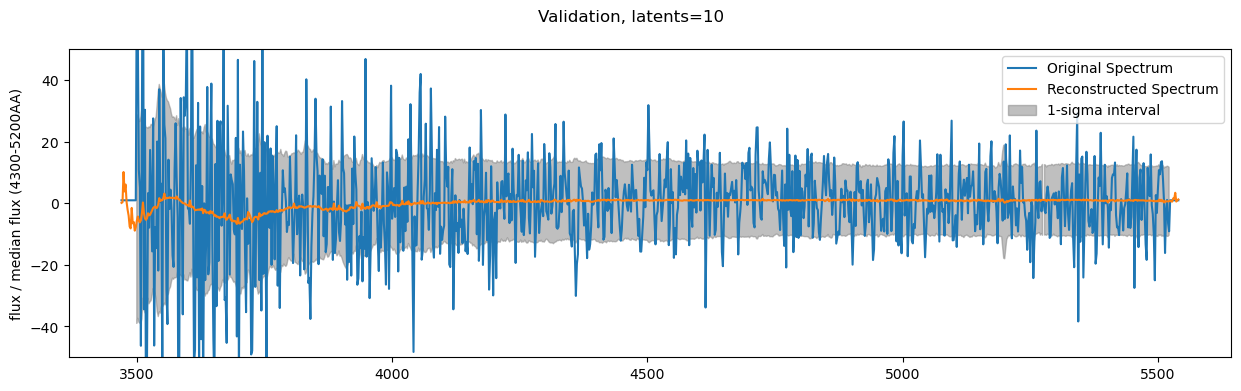

SpectrumAutoencoder(
  (encoder): SpectrumEncoder(
    (instrument): HETDEX()
    (conv1): Sequential(
      (0): Conv1d(1, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): InstanceNorm1d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): PReLU(num_parameters=128)
      (3): Dropout(p=0, inplace=False)
    )
    (conv2): Sequential(
      (0): Conv1d(128, 256, kernel_size=(11,), stride=(1,), padding=(5,))
      (1): InstanceNorm1d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): PReLU(num_parameters=256)
      (3): Dropout(p=0, inplace=False)
    )
    (conv3): Sequential(
      (0): Conv1d(256, 512, kernel_size=(21,), stride=(1,), padding=(10,))
      (1): InstanceNorm1d(512, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): PReLU(num_parameters=512)
      (3): Dropout(p=0, inplace=False)
    )
    (pool1): MaxPool1d(kernel_size=5, stride=5, padding=2, dilation=1, ceil_mode=False)
  

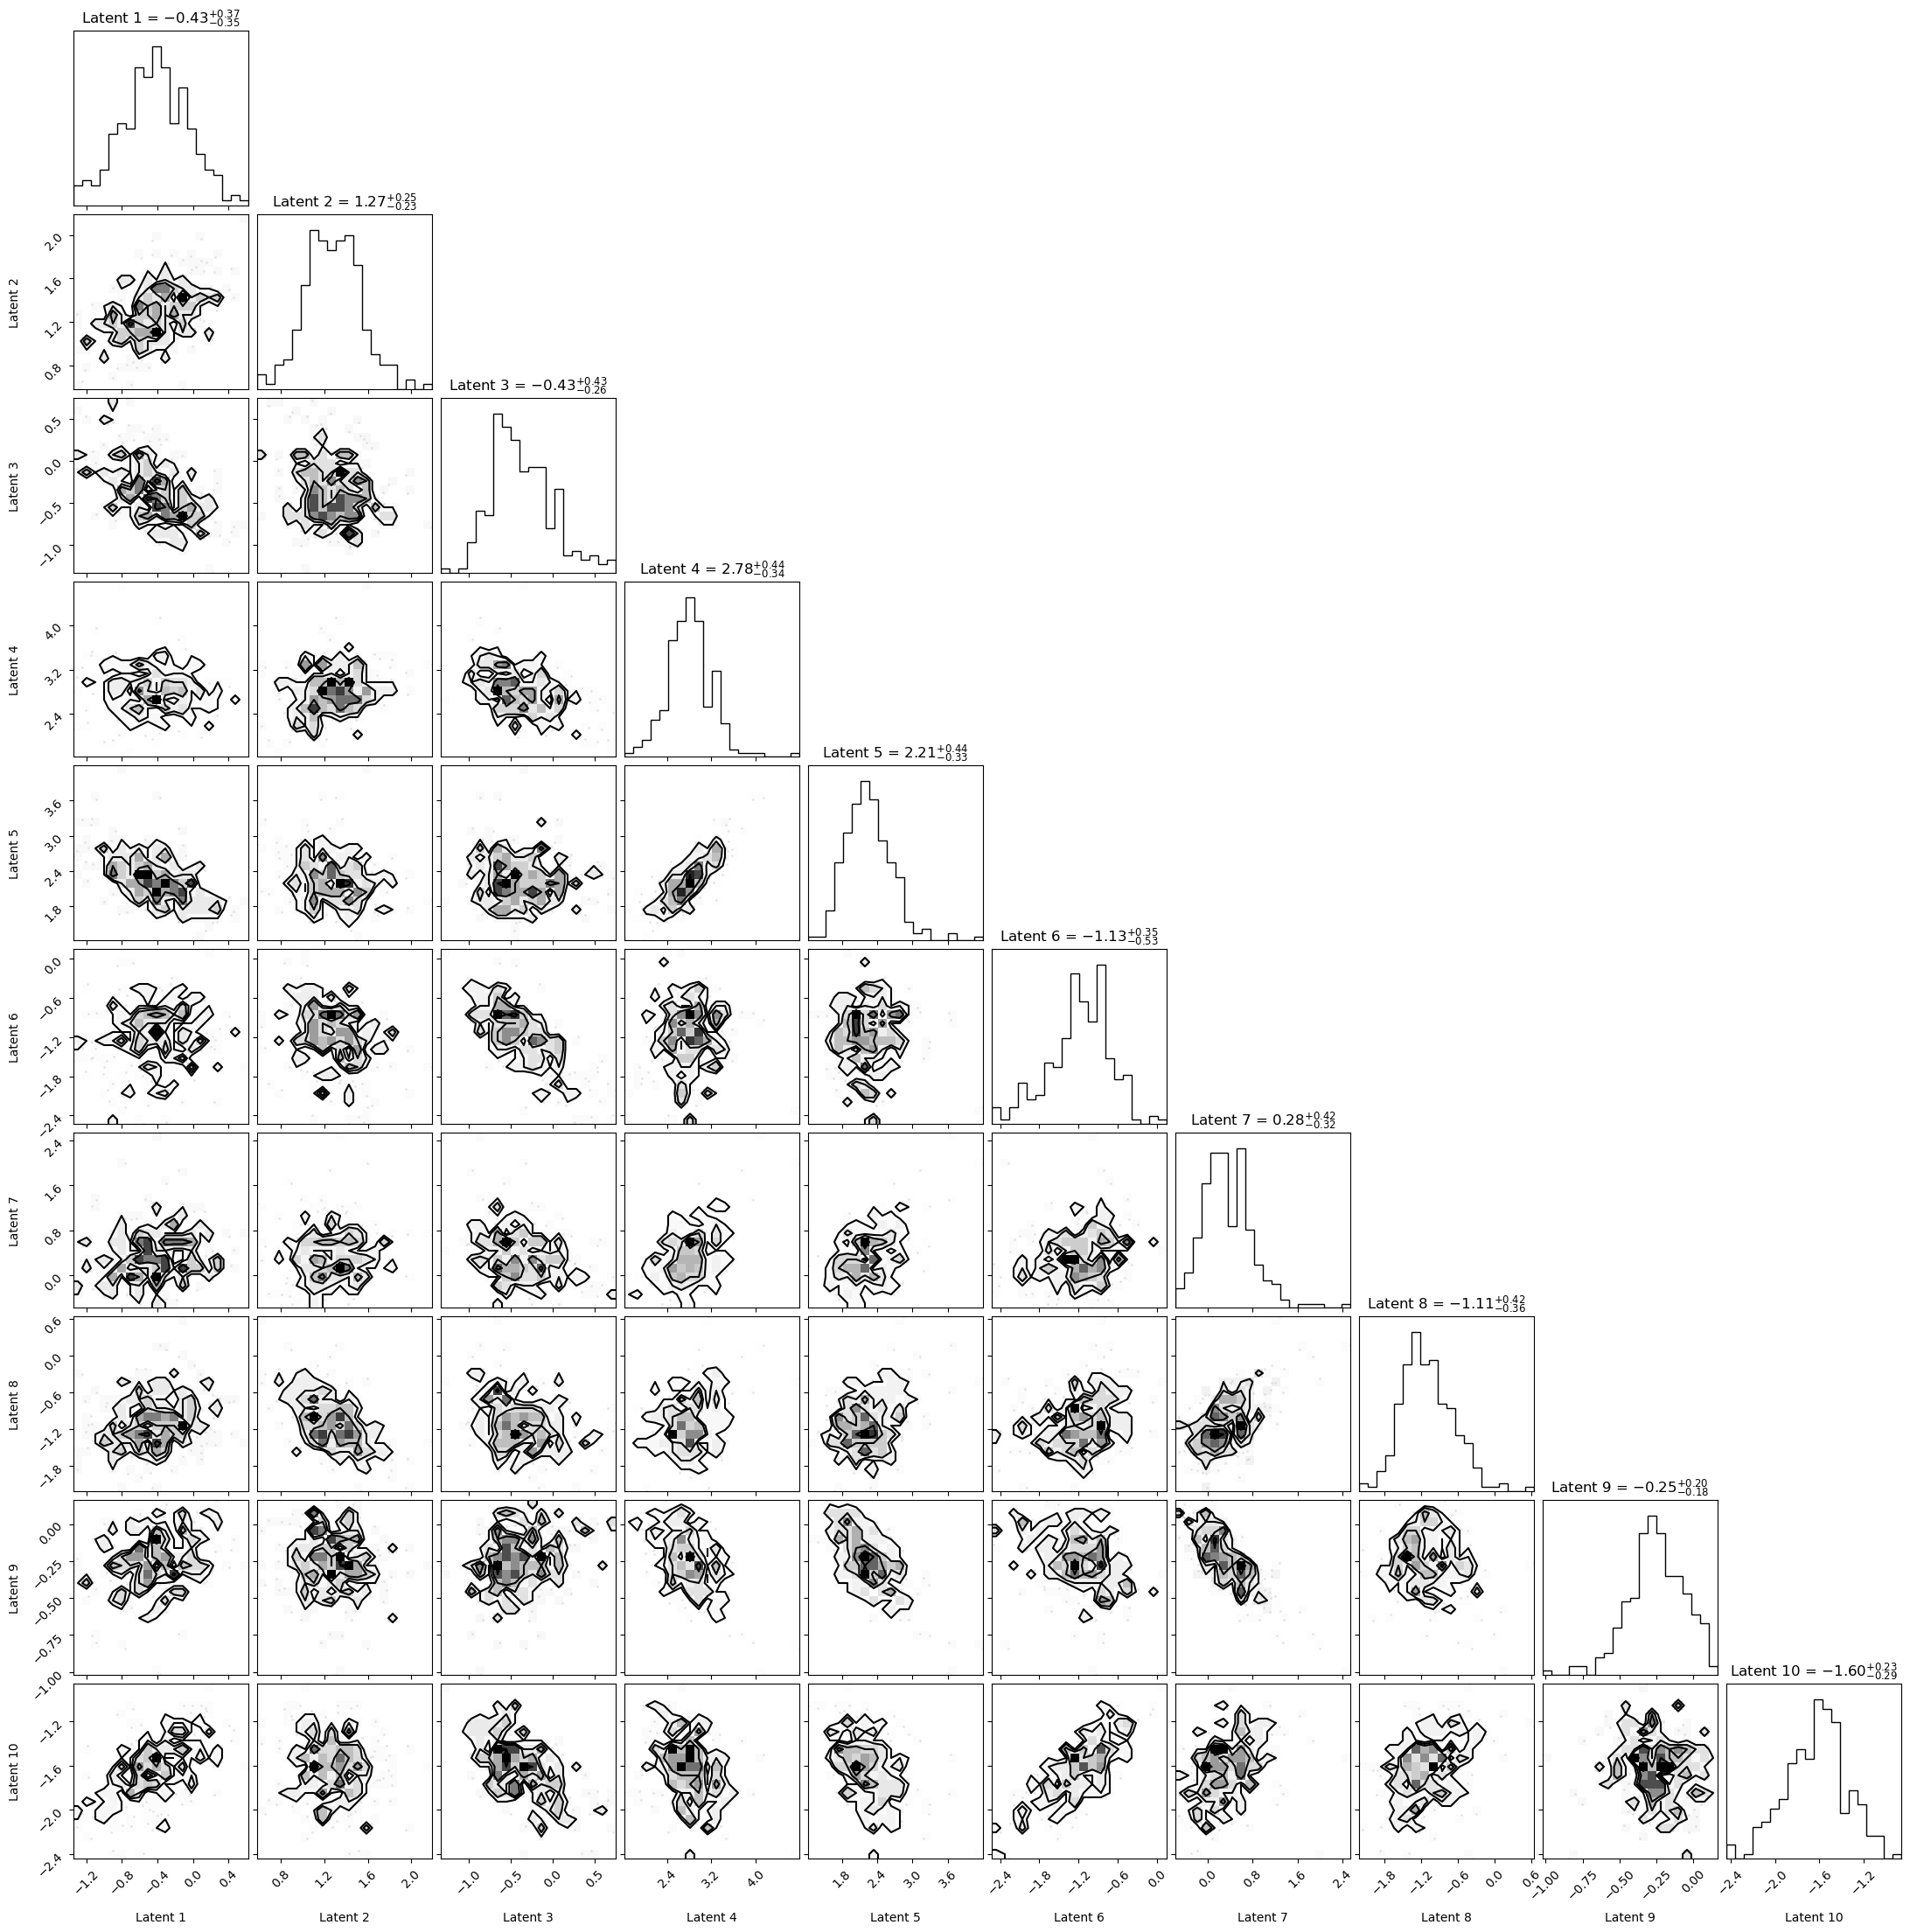

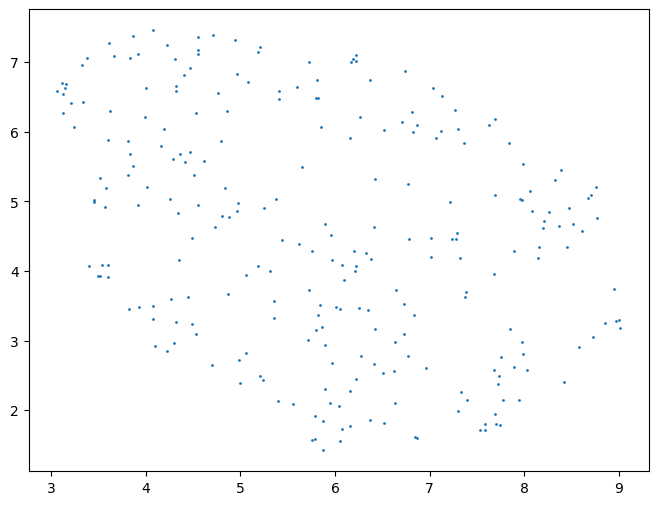

In [9]:
plot_diagnostic(saved_file = '/home/qezlou/projects/lae_detection/data/models/model_7e5_latents_10.pt', latents=10)

In [11]:
6_7771 * 25_000 /1e9

1.694275